### Import Libraries

In [1]:
import sys, os, re, json, joblib, getpass, warnings, time
from pathlib import Path
from functools import lru_cache
from collections import Counter

# make the project's `backend` package importable from notebooks/
if ".." not in sys.path:
    sys.path.insert(0, "..")

warnings.filterwarnings("ignore")
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

# --- core data / math ---
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# --- visualisation ---
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import TruncatedSVD

# --- NLP ---
import nltk
from nltk.stem import WordNetLemmatizer, PorterStemmer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from gensim.models import Word2Vec

# --- ML ---
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             balanced_accuracy_score, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier

# --- embeddings / GenAI ---
from sentence_transformers import SentenceTransformer
from google import genai

print(sys.executable)
print("All libraries loaded.")

D:\Downloads\nlp-finalproject-cinesquad-main\.venv\Scripts\python.exe
All libraries loaded.


## 2. Data Preprocessing & Normalization

### 2.1 Data Preprocessing 
The json file : reviews.json is loaded & inspected.Each item_id corresponds to a unique movie and each txt to a review about this movie.Then a labeled column ( positive or negative ) is created according to the existence of ranking in the context of txt column. If no ranking of the form( 8/10 , eight out of ten, eight/ten ) is found , then the review is deleted from the labeled dataset. 

In [2]:
base_dir = os.getcwd()
reviews_path = os.path.join(base_dir, os.path.pardir,
                            "movie_dataset_public_final", "raw", "reviews.json")
print("Reading:", os.path.abspath(reviews_path), "| exists:", os.path.exists(reviews_path))

# Inspect structure without loading all 2.6M records (JSON Lines: one object per line)
with open(reviews_path, encoding="utf-8") as f:
    sample = [json.loads(next(f)) for _ in range(5)]

print("fields per record:", list(sample[0].keys()))
pd.DataFrame(sample)

Reading: D:\Downloads\nlp-finalproject-cinesquad-main\movie_dataset_public_final\raw\reviews.json | exists: True
fields per record: ['item_id', 'txt']


,item_id,txt
0,172063,"one-shot record of a belly dancer; ""Carmencita..."
1,95541,Banging Away..; Thomas Edison and William K.L....
2,7065,unbelievable; I cannot understand how anyone c...
3,3739,I'm still starry-eyed from it; I saw this last...
4,1562,Failed on every Front; Joel Schumacher who did...


### Labeling 

In [3]:
# ============================================================
# LABELING  -  read per-review scores written in the text
# Handles:  8/10 | 8.5/10 | 8 out of 10 | 7 out of ten | eight out of ten
# ============================================================

WORD_NUMS = {"one":1,"two":2,"three":3,"four":4,"five":5,
             "six":6,"seven":7,"eight":8,"nine":9,"ten":10}

# score: digits (optional decimal) OR a spelled-out word
NUM   = r"(?:\d{1,2}(?:\.\d+)?|one|two|three|four|five|six|seven|eight|nine|ten)"
# separator: "/" or "out of"
SEP   = r"\s*(?:/|out\s+of)\s*"
# denominator: 10 or "ten"; \b stops "10 out of 100" reading as 10/10
DENOM = r"(?:10|ten)\b"
rating_pattern = re.compile(rf"({NUM}){SEP}{DENOM}", re.IGNORECASE)

def to_score(tok):
    t = tok.lower()
    return float(WORD_NUMS[t]) if t in WORD_NUMS else float(t)

labeled, drop_reasons, total = [], Counter(), 0
with open(reviews_path, encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue
        total += 1
        record  = json.loads(line)
        matches = rating_pattern.findall(record["txt"])

        if not matches:
            drop_reasons["no_match"] += 1
            continue

        # count DISTINCT values, not raw matches: "9/10 ... nine out of ten" -> {9.0}, keep it
        try:
            scores = {to_score(m) for m in matches}
        except (ValueError, KeyError):
            drop_reasons["unparseable"] += 1
            continue
        if len(scores) > 1:
            drop_reasons["conflicting_scores"] += 1   # e.g. "8/10 acting, 3/10 plot"
            continue

        score = scores.pop()
        if score < 1 or score > 10:
            drop_reasons["out_of_range"] += 1
            continue
        if score >= 7:
            label = "positive"
        elif score <= 4:
            label = "negative"
        else:
            drop_reasons["ambiguous_middle"] += 1     # 5, 6, 6.5 ...
            continue

        labeled.append({"item_id": record["item_id"], "text": record["txt"],
                        "score": score, "label": label})

print(f"Total records read: {total}")
print(f"Kept: {len(labeled)}")
print(drop_reasons)
print(Counter(r["label"] for r in labeled))

Total records read: 2624608
Kept: 211418
Counter({'no_match': 2342714, 'ambiguous_middle': 50493, 'conflicting_scores': 15694, 'out_of_range': 4289})
Counter({'positive': 171470, 'negative': 39948})


In [4]:
label_counts = Counter(r["label"] for r in labeled)
print(label_counts)

score_counts = Counter(r["score"] for r in labeled)
print(sorted(score_counts.items()))   # full score distribution 1-10

Counter({'positive': 171470, 'negative': 39948})
[(1.0, 8955), (1.1, 9), (1.125, 1), (1.2, 13), (1.3, 11), (1.4, 6), (1.5, 133), (1.51, 1), (1.6, 8), (1.7, 7), (1.8, 16), (1.9, 8), (2.0, 8100), (2.1, 15), (2.2, 13), (2.3, 20), (2.4, 14), (2.43, 1), (2.5, 191), (2.57, 1), (2.6, 15), (2.65, 1), (2.7, 8), (2.75, 2), (2.8, 35), (2.9, 15), (2.977, 1), (3.0, 9861), (3.1, 17), (3.2, 29), (3.25, 2), (3.3, 40), (3.333, 1), (3.4, 40), (3.5, 441), (3.6, 43), (3.666, 1), (3.7, 37), (3.75, 5), (3.8, 85), (3.9, 38), (4.0, 11708), (7.0, 35615), (7.1, 155), (7.12, 1), (7.125, 1), (7.2, 263), (7.25, 32), (7.3, 270), (7.33, 5), (7.35, 1), (7.4, 282), (7.43, 1), (7.5, 4698), (7.569, 1), (7.6, 276), (7.67, 1), (7.7, 211), (7.73, 1), (7.75, 45), (7.8, 408), (7.84, 1), (7.87, 1), (7.9, 659), (7.95, 1), (8.0, 40214), (8.07, 1), (8.08, 1), (8.1, 183), (8.12, 1), (8.15, 1), (8.2, 314), (8.25, 35), (8.26, 1), (8.3, 315), (8.33, 2), (8.35, 2), (8.372, 1), (8.4, 309), (8.45, 3), (8.5, 3865), (8.55, 1), (8.6, 220)

#### Analyzing Dataset Class Balance and Score Distributions 

In [ ]:
# Set up the plotting grid (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# Convert Counter data into a  DataFrame
labels_df = pd.DataFrame(list(label_counts.items()), columns=['Sentiment', 'Count'])

sns.barplot(
    x='Sentiment', 
    y='Count', 
    data=labels_df, 
    palette='Set1', 
    ax=axes[0]
)
axes[0].set_title("Distribution of Positive vs. Negative Reviews", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Class Label")
axes[0].set_ylabel("Number of Reviews")

# ========================================================
# Plot 2: Full Score Distribution (1-10 Breakdown)
# ========================================================
# Convert your sorted scores into a clean pandas DataFrame
scores_df = pd.DataFrame(sorted(score_counts.items()), columns=['Score', 'Count'])

scores_df['Score'] = scores_df['Score'].round().astype(int)

scores_df = scores_df.groupby('Score', as_index=False)['Count'].sum()


sns.barplot(
    x='Score', 
    y='Count', 
    data=scores_df, 
    palette='crest', # Beautiful smooth gradient color palette
    ax=axes[1]
)
sns.barplot(x='Score', y='Count', data=scores_df, palette='crest', ax=axes[1])
axes[1].bar_label(axes[1].containers[0], fmt='%d', padding=3)

# Adjust layout cleanly so text doesn't overlap
plt.tight_layout()
plt.show()

### Review Sentiment and Score Distribution Analysis

The charts illustrate the final target variable distributions across the pruned movie review dataset:

* **Distribution of Positive vs. Negative Reviews (Left):** The binary sentiment classes exhibit a clear imbalance. Positive reviews significantly outnumber negative reviews, with positive cases exceeding 170,000 records while negative reviews hover around 39,000. 
* **Full Review Score Distribution (Right):** The Score rating distribution provides granular context for this imbalance. The data is heavily skewed toward higher ratings, with  8 and 10 being the most frequent scores in the dataset. 

#### Modeling Implications
1. **Class Imbalance Handling:** Because positive samples are roughly 3 to 4 times more prevalent than negative ones, standard accuracy metrics may give a false sense of performance. Evaluation metrics such as Precision, Recall, and F1-Score must be utilized to properly monitor minority class performance.
2. **Missing Neutral Classes (Scores 5 & 6):** The clear gap between scores 4 and 7 perfectly visualizes our previous data-cleaning step (`ambiguous_5_6` filter). Removing these neutral reviews successfully isolated distinct positive and negative signals, which will help the classification model converge on sharper decision boundaries.

### Data Cleaning  

In [ ]:
# ============================================================
# BUILD DATAFRAME + DATA CLEANING
#   missing values, exact duplicates, short-review outliers, PII scan
# ============================================================
df = pd.DataFrame(labeled)
print("start:", len(df))

# 1. missing
print("NaN total:", int(df.isna().sum().sum()))
df = df.dropna().reset_index(drop=True)

# 2. exact-duplicate reviews (same raw text submitted more than once)
before = len(df)
df = df.drop_duplicates(subset="text").reset_index(drop=True)
print("dropped exact duplicates:", before - len(df))

# 3. inconsistency check: same text, different label (should be 0)
conflicts = df.groupby("text")["label"].nunique()
print("texts with conflicting labels:", int((conflicts > 1).sum()))

# 4. outliers: reviews under 5 words carry almost no signal
lens = df["text"].str.split().str.len()
before = len(df)
df = df[lens >= 5].reset_index(drop=True)
print("dropped <5-word reviews:", before - len(df))

# 5. PII scan (brief requires PII be removed/handled) -- report even if zero
emails = df["text"].str.contains(r"\S+@\S+\.\S+", regex=True).sum()
phones = df["text"].str.contains(r"\b\d{3}[-.]?\d{3}[-.]?\d{4}\b", regex=True).sum()
print("emails found:", int(emails), "| phone-like:", int(phones))

print("final:", len(df))
os.makedirs("../movie_dataset_public_final/processed", exist_ok=True)
df.to_csv("../movie_dataset_public_final/processed/labeled_reviews.csv", index=False)
df.head()

## 2.2 Data Normalization
### Text Preprocessing, Normalization, and Lexical Tokenization Pipeline

###  Removal of Explicit Review Ratings (Preventing Data Leakage)

During the text preprocessing phase , a regular expression pattern was used to scan the raw text data and strip out explicit strings matching text scores (such as "8/10","8 out of 10", "eight/ten" , "eight of ten" ). 
This preprocessing step is a critical requirement due to **Label Leakage**:
If left uncleaned, a machine learning model or NLP classifier will bypass the complex work of analyzing linguistic sentiment. Instead, it will simply lock onto the digits `7/10` to cheat its way to a perfect prediction during training. This creates an artificially inflated evaluation score during validation, but results in poor performance in production when evaluating real-world text that lacks an explicit score suffix.

In [7]:
# Remove the in-text rating so the model can't cheat by reading the score (label leakage).
# Same pattern as the labeler (digits/decimals/words, "/" or "out of"), no capture group.
strip_pattern = rf"{NUM}{SEP}{DENOM}"
df["text_clean"] = df["text"].str.replace(strip_pattern, " ", regex=True, flags=re.IGNORECASE)

In [8]:
# Sanity check: must be 0 -- reuse the labeler's compiled pattern so the check can't drift
remaining = df["text_clean"].str.contains(rating_pattern, regex=True).sum()
print("Rows still containing a rating pattern:", int(remaining))

Rows still containing a rating pattern: 0


### Advanced Text Normalization Pipeline

To prepare the raw movie review text for NLP modeling, an advanced normalization function (`advanced_normalize_text`) was implemented. This pipeline transforms noisy, unstructured user text into a clean sequence of meaningful words (tokens) through a multi-stage cleaning process:

#### Noise Reduction & Text Cleaning
* **HTML & URL Removal:** Strips out web artifacts such as HTML tags (`<.*?>`) and web links (`http/https/www`), which do not contribute to sentiment.
* **Social Media Filtering:** Removes user handles (`@mentions`) and hashtags (`#topic`) often found in modern text data.
* **Character Standardizing:** Drops emojis and non-standard keyboard characters by forcing ASCII encoding, and converts all characters to **lowercase**.
* **Elongated Word Fix:** Uses regular expressions to fix exaggerated repeating letters (e.g., changing `"looooove"` to `"loove"`), which helps compress varying spellings into a single recognizable word.
* **Punctuation Stripping:** Removes all numbers, special characters, and punctuation markers, keeping only raw letters (`a-z`).
* **Intelligent Stopword Filtering:** Standard English stopwords (like *"the"*, *"is"*) are removed to focus on content-heavy words. **Crucially, negation words (`not`, `no`, `never`, `nor`) are intentionally kept** in the vocabulary since removing them would destroy the core meaning of a negative review (e.g., turning *"not good"* into *"good"*).
* **Length Pruning:** Drops ultra-short words (less than 2 characters, such as *"a"* or *"i"*) to decrease vocabulary noise.

In [9]:
# ============================================================
# ADVANCED TEXT NORMALIZATION
# NOTE: this same function is duplicated in backend/services/text_normalizer.py
#       so the saved sentiment Pipeline can normalize raw text at serving time.
# ============================================================
negations    = {"not", "no", "never", "nor"}
custom_stops = set(ENGLISH_STOP_WORDS) - negations
lemmatizer   = WordNetLemmatizer()
stemmer      = PorterStemmer()

@lru_cache(maxsize=200_000)
def cached_stem(token):
    return stemmer.stem(token)

# Contractions expanded BEFORE punctuation is stripped, or "don't" -> "don"+"t",
# the "t" is dropped, and the negation is lost. Order matters: can't/won't first.
CONTRACTIONS = [
    (re.compile(r"\bcan't\b", re.IGNORECASE), "can not"),
    (re.compile(r"\bwon't\b", re.IGNORECASE), "will not"),
    (re.compile(r"n't\b",     re.IGNORECASE), " not"),   # don't, isn't, didn't ...
]

# PII patterns -- must run before the @handle strip, or "@" eats the email host
RE_EMAIL   = re.compile(r"\S+@\S+\.\S+")
RE_PHONE   = re.compile(r"\b(?:\+?\d{1,3}[-.\s]?)?\(?\d{3}\)?[-.\s]?\d{3}[-.\s]?\d{4}\b")
RE_HTML    = re.compile(r"<.*?>")
RE_URL     = re.compile(r"https?://\S+|www\.\S+")
RE_HANDLE  = re.compile(r"@\w+|#\w+")
RE_REPEAT  = re.compile(r"(.)\1{2,}")      # 3+ identical chars in a row
RE_NONALPHA = re.compile(r"[^a-z\s]")

def advanced_normalize_text(text, mode="stem"):
    """mode: 'none' | 'stem' | 'lemma'.  Returns a STRING (TfidfVectorizer wants strings)."""
    if not isinstance(text, str):
        return ""
    text = RE_HTML.sub(" ", text)                          # HTML
    text = RE_URL.sub(" ", text)                           # URLs
    text = RE_EMAIL.sub(" ", text)                         # PII: emails
    text = RE_PHONE.sub(" ", text)                         # PII: phone numbers
    text = RE_HANDLE.sub(" ", text)                        # @mentions / #hashtags
    text = text.encode("ascii", "ignore").decode("ascii") # emoji / non-ASCII
    for pat, repl in CONTRACTIONS:                         # contractions (before punctuation)
        text = pat.sub(repl, text)
    text = RE_REPEAT.sub(r"\1", text)                      # "Looove" -> "Love"
    text = text.lower()
    text = RE_NONALPHA.sub(" ", text)                      # keep letters + spaces

    out = []
    for tok in text.split():
        if tok in custom_stops or len(tok) <= 1:
            continue
        if mode == "stem":
            tok = cached_stem(tok)
        elif mode == "lemma":
            tok = lemmatizer.lemmatize(tok)                # noun-mode: movies->movie
        out.append(tok)
    return " ".join(out)

# quick check -- both negations must survive as the word "not"
print(advanced_normalize_text("I DON'T like it, it was sooooo boring. can't recommend."))

not like bore not recommend


In [10]:
print("Executing normalization (mode='stem') ...")

df["tokens"] = df["text_clean"].apply(lambda t: advanced_normalize_text(t, mode="stem"))

# a review that was only a score + stopwords normalizes to "" -> drop (empty doc, useless)
before = len(df)
df = df[df["tokens"].str.strip() != ""].reset_index(drop=True)
print("dropped empty-after-normalization:", before - len(df))

# leakage guard: near-duplicates that only collapse AFTER normalization
# (differ only by punctuation/casing). tokens is what the model trains on.
before = len(df)
df = df.drop_duplicates(subset="tokens").reset_index(drop=True)
print("dropped normalized duplicates:", before - len(df))

print("rows:", len(df))
os.makedirs("../data", exist_ok=True)
df.to_pickle("../data/labeled_stem.pkl")   # cache so a kernel restart skips the slow steps
print(df[["text", "tokens"]].head())

Executing normalization (mode='stem') ...
dropped empty-after-normalization: 0
dropped normalized duplicates: 141
rows: 210856
                                                text  \
0  Failed on every Front; Joel Schumacher who did...   
1  An Accomplished Tim Burton Movie; A Great Idea...   
2  What a great change; Now, the stereotypical Di...   
3  Good, But Not For Everyone; A truly original e...   
4  Brilliant. This one matches -if not out stands...   

                                              tokens  
0  fail joel schumach did ok job batman movi simp...  
1  accomplish tim burton movi great idea good scr...  
2  great chang stereotyp disney channel movi hoor...  
3  good not truli origin exampl movi make concept...  
4  brilliant match not stand big lebowski quit cr...  


### Deciding on Stemming vs. Lemmatization

Same 30k stratified subsample and the same classifier for every mode; only the
morphological reduction changes. We report macro-F1 (imbalance-aware) and the
resulting vocabulary size, with bigrams and again with unigrams only.

In [11]:
# ---- Stemming vs Lemmatization vs None (30k subsample, LogReg) ----
_sub, _ = train_test_split(df, train_size=30000, random_state=42, stratify=df["label"])

def _run(ngram):
    print(f"\n== ngram_range={ngram} ==")
    for mode in ["none", "stem", "lemma"]:
        X = _sub["text_clean"].apply(lambda t: advanced_normalize_text(t, mode=mode))
        Xtr, Xte, ytr, yte = train_test_split(
            X, _sub["label"], test_size=0.2, random_state=42, stratify=_sub["label"])
        vec = TfidfVectorizer(ngram_range=ngram, min_df=5, sublinear_tf=True)
        Xtr_v, Xte_v = vec.fit_transform(Xtr), vec.transform(Xte)
        clf = LogisticRegression(max_iter=1000, class_weight="balanced").fit(Xtr_v, ytr)
        f1 = f1_score(yte, clf.predict(Xte_v), average="macro")
        print(f"  {mode:6}  macro_F1={f1:.4f}   vocab={len(vec.vocabulary_)}")

_run((1, 2))   # with bigrams
_run((1, 1))   # unigrams only -- this is where stemming's vocabulary shrink shows

# Decision: stemming gives the smallest unigram vocabulary (largest feature collapse)
# at no meaningful cost in macro-F1, so we normalize with mode="stem" everywhere.


== ngram_range=(1, 2) ==
  none    macro_F1=0.8606   vocab=94087
  stem    macro_F1=0.8579   vocab=98200
  lemma   macro_F1=0.8612   vocab=95227

== ngram_range=(1, 1) ==
  none    macro_F1=0.8500   vocab=25994
  stem    macro_F1=0.8405   vocab=17693
  lemma   macro_F1=0.8463   vocab=23218


###  Dataset Splitting and Stratification

To properly train and evaluate the sentiment models, the cleaned dataset was partitioned into isolated training and testing subsets using Scikit-Learn's `train_test_split`. 

The function parameters were configured to ensure statistical rigor and reproducibility:

* **Features ($X$) and Target ($y$):** The input features ($X$) consist of the preprocessed word tokens (`df['tokens']`), and the target variable ($y$) is the binary sentiment class (`df['label']`).
* **Test Size (`test_size=0.2`):** The dataset was split into an **80/20 ratio**. 80% of the data is allocated to train the machine learning models, while 20% is completely held out as an unseen test set to evaluate real-world generalization performance.
* **Stratification (`stratify=df["label"]`):** This is a critical parameter due to the severe class imbalance we found in our data exploration (where positive reviews make up roughly 81% and negative reviews make up 19%). Stratification forces the split to maintain this exact 81% to 19% ratio in *both* the training set and the test set. Without this, one split might accidentally receive all the positive reviews, causing biased training or misleading test evaluations.
* **Reproducibility (`random_state=42`):** Setting a static random seed ensures that the shuffle-and-split math behaves identically every time the notebook is run, guaranteeing reproducible experiments and consistent results.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    df["tokens"],           # stemmed, space-joined review text
    df["label"],            # positive / negative
    test_size=0.2,
    stratify=df["label"],   # preserve the class ratio in both splits
    random_state=42,
)
print(X_train.shape, X_test.shape)
print("train:", dict(y_train.value_counts(normalize=True).round(3)))
print("test :", dict(y_test.value_counts(normalize=True).round(3)))

(168684,) (42172,)
train: {'positive': np.float64(0.811), 'negative': np.float64(0.189)}
test : {'positive': np.float64(0.811), 'negative': np.float64(0.189)}


## 3 Feature Engineering (Embeddings) & Text Visualization

### 3.1
### Justification for Choosing TF-IDF
* **Explicit Keyword Weighting**: Automatically calculates and scales up the mathematical importance of distinct "clue" words (like terrible or excellent) while suppressing common background noise words.
* **Linear Separability**: Creates a high-dimensional, sparse matrix that perfectly matches the mathematical strengths of linear classifiers (e.g., Logistic Regression, SVM), allowing them to draw clean decision boundaries with low computational overhead.
 ### Adding $N$-grams
* **Preserves Context**: Captures word order by grouping adjacent pairs (e.g., "not good", "highly recommend") instead of treating words completely in isolation. Crucial for accurate text classification because it keeps negative modifiers attached to their targets, preventing the model from misinterpreting a flipped sentiment or topic.

In [13]:
# TF-IDF features.
# advanced_normalize_text already returns space-joined STRINGS, so no list->str step.
# No stop_words= : we already filtered, and sklearn's list would strip our negations.
vectorizer = TfidfVectorizer(
    max_features=40000,
    ngram_range=(1, 2),
    min_df=5,
    sublinear_tf=True,
)
X_train_tfidf = vectorizer.fit_transform(X_train)   # fit on TRAIN only
X_test_tfidf  = vectorizer.transform(X_test)        # transform only -> no leakage

print(X_train_tfidf.shape, X_test_tfidf.shape)
print("vocab size:", len(vectorizer.vocabulary_))

(168684, 40000) (42172, 40000)
vocab size: 40000


### 3.2 Building the Top-$N$ Similar Words Solution.

In [14]:
# ============================================================
# 3.2  Top-N similar words  ->  Word2Vec (with bigram phrases)
# Trained on UNSTEMMED text so results are readable ("movie", not "movi").
# ============================================================
from gensim.models.phrases import Phrases, Phraser

# tokenise text_clean without stemming (mode="none" keeps real English words)
w2v_sentences = [advanced_normalize_text(t, mode="none").split() for t in df["text_clean"]]

# learn common bigrams ("special_effects", "waste_time") and fold them in as tokens
bigram = Phraser(Phrases(w2v_sentences, min_count=20, threshold=10))
w2v_sentences = [bigram[s] for s in w2v_sentences]

w2v = Word2Vec(
    w2v_sentences,
    vector_size=100,   # embedding dimension
    window=5,          # context window
    min_count=5,       # ignore very rare words
    workers=4,
    seed=42,
)
print("vocab:", len(w2v.wv))

def similar_words(word, n=8):
    word = word.lower()
    if word not in w2v.wv:
        print(f"'{word}' not in vocabulary"); return
    print(f"Top {n} similar to '{word}':")
    for w, s in w2v.wv.most_similar(word, topn=n):
        print(f"  {w:20} {s:.3f}")

similar_words("good")
similar_words("awful")
# Note: 'good' ~ 'bad' is expected -- Word2Vec captures CONTEXT, not sentiment,
# which is exactly why a supervised classifier is still needed for Task 1.

vocab: 90018
Top 8 similar to 'good':
  pretty_good          0.836
  great                0.805
  decent               0.791
  pretty_decent        0.748
  nice                 0.709
  bad                  0.708
  alright              0.704
  solid                0.702
Top 8 similar to 'awful':
  terrible             0.929
  horrible             0.892
  atrocious            0.872
  god_awful            0.867
  horrendous           0.854
  abysmal              0.846
  dreadful             0.830
  appalling            0.801


### 3.3 The t-SNE Document Visualization Script

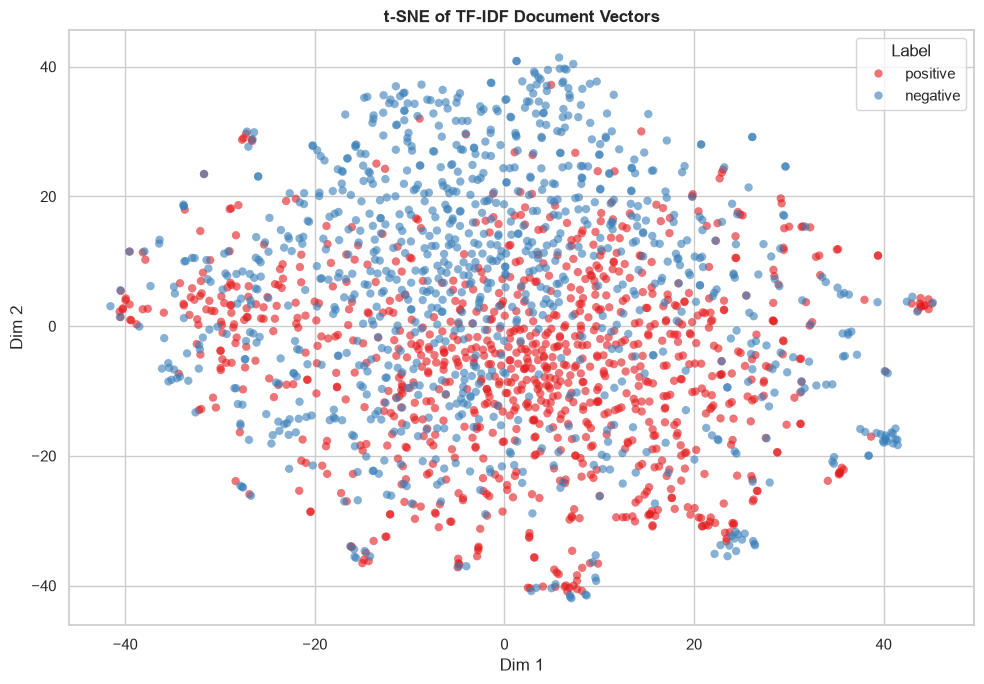

In [15]:
# ============================================================
# 3.3  t-SNE of TF-IDF document vectors (coloured by sentiment)
# SVD (sparse) 40k -> 50 dims, then t-SNE 50 -> 2. Balanced 2k sample for a readable plot.
# ============================================================
sns.set_theme(style="whitegrid")
rng = np.random.RandomState(42)
y_arr = y_train.values
pos = np.where(y_arr == "positive")[0]
neg = np.where(y_arr == "negative")[0]
m   = min(1000, len(neg))
rows = np.concatenate([rng.choice(pos, m, replace=False),
                       rng.choice(neg, m, replace=False)])

X_small = TruncatedSVD(n_components=50, random_state=42).fit_transform(X_train_tfidf[rows])
coords  = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_small)

plot_data = pd.DataFrame({"Dim 1": coords[:, 0], "Dim 2": coords[:, 1],
                          "Label": y_arr[rows]})
plt.figure(figsize=(10, 7))
sns.scatterplot(x="Dim 1", y="Dim 2", hue="Label", data=plot_data,
                palette="Set1", alpha=0.6, edgecolor="none")
plt.title("t-SNE of TF-IDF Document Vectors", fontweight="bold")
plt.tight_layout()
plt.show()

### t-SNE Diagram Analysis 

t-SNE shows heavy overlap between classes, indicating that sentiment is not separable by overall document similarity in TF-IDF space. This is expected: sentiment is carried by a small number of discriminative terms rather than by global vector geometry, and a 40,000→2 projection cannot preserve the specific dimensions the linear classifier exploits. The classifier's ~0.86 macro-F1 confirms the separation exists in the full space; the overlap here reflects the limits of 2D visualization, not weak features.

## 4. Model Building

### 4.1 Unsupervised Learning 

### 4.2 Supervised Learning

In [16]:
results = {}   # each model appends here for the final comparison

def evaluate(name, model, X_te, y_te):
     """Train already done; this scores on the untouched test set and stores key metrics."""
     y_pred = model.predict(X_te)
     rep = classification_report(y_te, y_pred, output_dict=True)
     results[name] = {
         "accuracy":      rep["accuracy"],
         "neg_recall":    rep["negative"]["recall"],      
         "neg_precision": rep["negative"]["precision"],
         "neg_f1":        rep["negative"]["f1-score"],
         "macro_f1":      rep["macro avg"]["f1-score"],    
         "balanced_acc":  balanced_accuracy_score(y_te, y_pred),
     }
     print(f"========================== {name} =====================================")
     print(classification_report(y_te, y_pred))
     print("Confusion matrix [rows=true, cols=pred], classes:", model.classes_)
     print(confusion_matrix(y_te, y_pred))
     print()

## Machine Learning Models 

### 1ST MODEL: LOGISTIC REGRESSION

In [17]:
logreg = LogisticRegression(class_weight="balanced", max_iter=1000)
logreg.fit(X_train_tfidf, y_train)
evaluate("LogisticRegression", logreg, X_test_tfidf, y_test)

========================== LogisticRegression =====================================
              precision    recall  f1-score   support

    negative       0.73      0.89      0.80      7974
    positive       0.97      0.92      0.95     34198

    accuracy                           0.92     42172
   macro avg       0.85      0.91      0.88     42172
weighted avg       0.93      0.92      0.92     42172

Confusion matrix [rows=true, cols=pred], classes: ['negative' 'positive']
[[ 7073   901]
 [ 2576 31622]]



### 2ND MODEL: LINEAR SUPPORT VECTOR CLASSIFIER 

In [18]:
linsvm = LinearSVC(class_weight="balanced", max_iter=2000, dual="auto")
linsvm.fit(X_train_tfidf, y_train)
evaluate("LinearSVM", linsvm, X_test_tfidf, y_test)

========================== LinearSVM =====================================
              precision    recall  f1-score   support

    negative       0.72      0.84      0.78      7974
    positive       0.96      0.92      0.94     34198

    accuracy                           0.91     42172
   macro avg       0.84      0.88      0.86     42172
weighted avg       0.92      0.91      0.91     42172

Confusion matrix [rows=true, cols=pred], classes: ['negative' 'positive']
[[ 6698  1276]
 [ 2570 31628]]



### 3RD MODEL:  RANDOM FOREST CLASSIFIER 

In [19]:
rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", n_jobs=-1, random_state=42)
rf.fit(X_train_tfidf, y_train)
evaluate("RandomForest", rf, X_test_tfidf, y_test)

========================== RandomForest =====================================
              precision    recall  f1-score   support

    negative       0.80      0.68      0.74      7974
    positive       0.93      0.96      0.94     34198

    accuracy                           0.91     42172
   macro avg       0.87      0.82      0.84     42172
weighted avg       0.90      0.91      0.91     42172

Confusion matrix [rows=true, cols=pred], classes: ['negative' 'positive']
[[ 5446  2528]
 [ 1340 32858]]



### Compare the 3 models 

In [20]:
comparison = pd.DataFrame(results).T
print(comparison.round(3).sort_values("macro_f1", ascending=False))

                    accuracy  neg_recall  neg_precision  neg_f1  macro_f1  \
LogisticRegression     0.918       0.887          0.733   0.803     0.875   
LinearSVM              0.909       0.840          0.723   0.777     0.860   
RandomForest           0.908       0.683          0.803   0.738     0.841   

                    balanced_acc  
LogisticRegression         0.906  
LinearSVM                  0.882  
RandomForest               0.822  


### Winner: Logistic Regression

Across the three sparse-feature models, Logistic Regression leads on macro-F1 and
balanced accuracy while keeping the strongest negative-class recall.

### Comparing Embedding Techniques

Same classifier (LogReg) and the same 30k rows for all three representations, so any
difference is attributable to the **embedding**, not the model.
macro-F1 is reported , alongside dimensionality and encode time (the advantages/disadvantages axis).

In [21]:
# smaller sample 
sample, _ = train_test_split(df, train_size=8000, random_state=42, stratify=df["label"])
train_part, test_part = train_test_split(
    sample, test_size=0.2, random_state=42, stratify=sample["label"]
)
y_train_e, y_test_e = train_part["label"], test_part["label"]

embedding_results = {}   # collect each method's score here

def evaluate_embedding(name, X_train_vec, X_test_vec, seconds):
    """Train LogReg on the given vectors and record macro-F1, size, and speed."""
    model = LogisticRegression(max_iter=1000, class_weight="balanced")
    model.fit(X_train_vec, y_train_e)
    macro_f1 = f1_score(y_test_e, model.predict(X_test_vec), average="macro")

    embedding_results[name] = {
        "macro_f1":   round(macro_f1, 4),
        "dimensions": X_train_vec.shape[1],   # how many numbers per document
        "encode_sec": round(seconds, 1),      # how long the vectors took to build
    }
    print(f"{name:14} | macro-F1 = {macro_f1:.4f} | dims = {X_train_vec.shape[1]:>5} | {seconds:.1f}s")

# --- A. TF-IDF : sparse, based on exact words -------------------------
start = time.time()
tfidf = TfidfVectorizer(max_features=40000, ngram_range=(1, 2), min_df=5, sublinear_tf=True)
X_train_tfidf_e = tfidf.fit_transform(train_part["tokens"])   # fit on train only
X_test_tfidf_e  = tfidf.transform(test_part["tokens"])
evaluate_embedding("TF-IDF", X_train_tfidf_e, X_test_tfidf_e, time.time() - start)

# --- B. Word2Vec (averaged) : dense, based on word meaning ------------
# Each word has a vector; we average them to get one vector per review.
# averaging loses word order, so "not good" ≈ "good".
def document_vector(text):
    words = advanced_normalize_text(text, mode="none").split()
    word_vecs = [w2v.wv[w] for w in words if w in w2v.wv]
    if len(word_vecs) == 0:
        return np.zeros(w2v.vector_size)      # review had no known words
    return np.mean(word_vecs, axis=0)

start = time.time()
X_train_w2v = np.vstack([document_vector(t) for t in train_part["text_clean"]])
X_test_w2v  = np.vstack([document_vector(t) for t in test_part["text_clean"]])
evaluate_embedding("Word2Vec-avg", X_train_w2v, X_test_w2v, time.time() - start)

# --- C. MiniLM : dense, understands whole sentences -------------------
start = time.time()
minilm = SentenceTransformer("all-MiniLM-L6-v2")
X_train_minilm = minilm.encode(train_part["text_clean"].tolist(),
                               batch_size=64, show_progress_bar=True)
X_test_minilm  = minilm.encode(test_part["text_clean"].tolist(),
                               batch_size=64, show_progress_bar=True)
evaluate_embedding("MiniLM", X_train_minilm, X_test_minilm, time.time() - start)
# --- Results table ---------------------------------------------------
print("\nComparison of embedding techniques:")
print(pd.DataFrame(embedding_results).T)

TF-IDF         | macro-F1 = 0.8553 | dims = 26640 | 5.3s
Word2Vec-avg   | macro-F1 = 0.8281 | dims =   100 | 6.3s


Batches: 100%|██████████| 25/25 [00:45<00:00,  1.83s/it]

MiniLM         | macro-F1 = 0.7357 | dims =   384 | 238.4s

Comparison of embedding techniques:
              macro_f1  dimensions  encode_sec
TF-IDF          0.8553     26640.0         5.3
Word2Vec-avg    0.8281       100.0         6.3
MiniLM          0.7357       384.0       238.4


### Embedding Comparison Result Analysis
A general-purpose transformer embedding scored lowest (0.74), below both TF-IDF (0.86) and averaged Word2Vec (0.82). MiniLM optimizes for semantic similarity, not sentiment polarity — sentences with opposite sentiment but similar meaning are placed close together, which a linear classifier cannot separate. This shows that embedding sophistication does not guarantee task performance: the representation must match what the task actually discriminates on.

### Word-Frequency Visualizations

Most frequent words per class (shared vocabulary motivates IDF weighting)

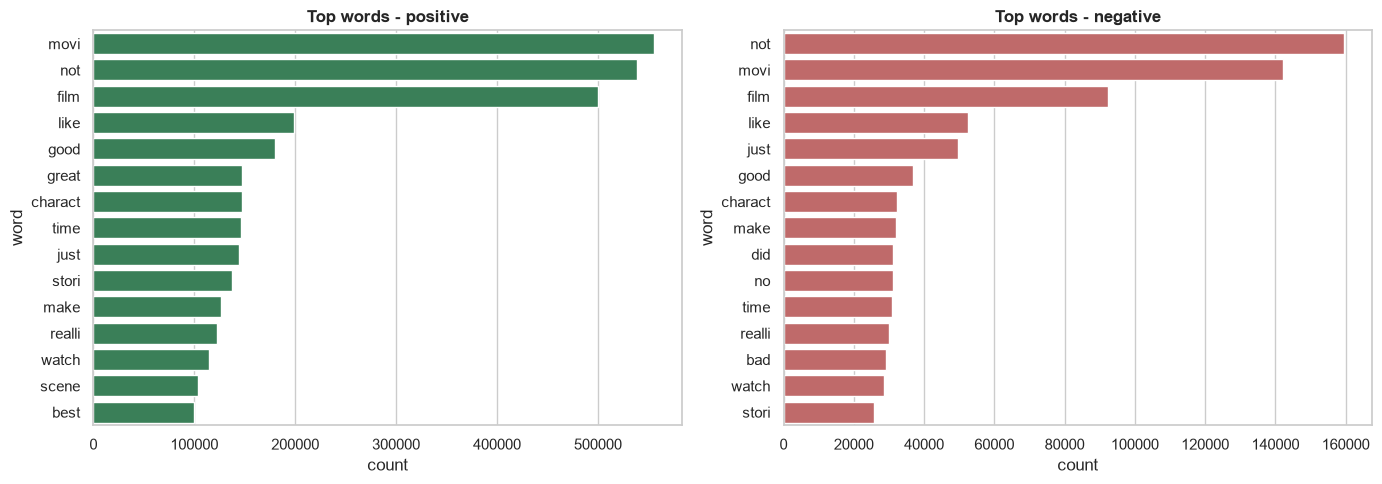

In [22]:
# Top-15 words per class
pos_w = Counter(" ".join(df[df["label"]=="positive"]["tokens"]).split())
neg_w = Counter(" ".join(df[df["label"]=="negative"]["tokens"]).split())

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for a, cnt, ttl, col in [(ax[0], pos_w, "Top words - positive", "seagreen"),
                         (ax[1], neg_w, "Top words - negative", "indianred")]:
    top = pd.DataFrame(cnt.most_common(15), columns=["word","count"])
    sns.barplot(data=top, y="word", x="count", ax=a, color=col)
    a.set_title(ttl, fontweight="bold")
plt.tight_layout(); plt.show()

## Deep Learning Model 

In [23]:
# For a fair comparison the MLP is trained on the SAME split as the other models.
# MLPClassifier has no class_weight, so the imbalance is unmitigated here --
print("MLP will train on the full training split:", len(y_train), "rows")

MLP will train on the full training split: 168684 rows


### Embed the balanced training set and the full test set

In [24]:
# ============================================================
# MiniLM sentence embeddings for the DL model.
# Encode text_clean (real English), aligned to the CURRENT split.
# Cache is reused ONLY if its row count matches -- guards against stale files.
# ============================================================
emb_dir    = os.path.join(os.path.dirname(os.getcwd()), "embeddings")
train_path = os.path.join(emb_dir, "X_train_emb.npy")
test_path  = os.path.join(emb_dir, "X_test_emb.npy")

encoder = SentenceTransformer("all-MiniLM-L6-v2")

rebuild = True
if os.path.exists(train_path) and os.path.exists(test_path):
    ctr, cte = np.load(train_path), np.load(test_path)
    if ctr.shape[0] == len(y_train) and cte.shape[0] == len(y_test):
        X_train_emb, X_test_emb, rebuild = ctr, cte, False
        print("Loaded cached embeddings:", X_train_emb.shape, X_test_emb.shape)
    else:
        print("Cache stale -> re-embedding")

if rebuild:
    X_train_emb = encoder.encode(df.loc[X_train.index, "text_clean"].tolist(),
                                 batch_size=64, show_progress_bar=True)
    X_test_emb  = encoder.encode(df.loc[X_test.index, "text_clean"].tolist(),
                                 batch_size=64, show_progress_bar=True)
    os.makedirs(emb_dir, exist_ok=True)
    np.save(train_path, X_train_emb); np.save(test_path, X_test_emb)
    print("Encoded & cached:", X_train_emb.shape, X_test_emb.shape)

assert X_train_emb.shape[0] == len(y_train)
assert X_test_emb.shape[0]  == len(y_test)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1741.96it/s]


Loaded cached embeddings: (168684, 384) (42172, 384)


### Train and evaluate the Multi-Layer Perceptron (MLP) 

In [25]:
# MLP head on the frozen MiniLM embeddings.
mlp = MLPClassifier(hidden_layer_sizes=(128,), activation="relu",
                    max_iter=300, early_stopping=True, random_state=42)
mlp.fit(X_train_emb, y_train)            # same labels/rows as the other models
evaluate("MLP_MiniLM", mlp, X_test_emb, y_test)

comparison = pd.DataFrame(results).T
print(comparison.round(3).sort_values("macro_f1", ascending=False))

========================== MLP_MiniLM =====================================
              precision    recall  f1-score   support

    negative       0.75      0.59      0.66      7974
    positive       0.91      0.96      0.93     34198

    accuracy                           0.89     42172
   macro avg       0.83      0.77      0.79     42172
weighted avg       0.88      0.89      0.88     42172

Confusion matrix [rows=true, cols=pred], classes: ['negative' 'positive']
[[ 4665  3309]
 [ 1533 32665]]

                    accuracy  neg_recall  neg_precision  neg_f1  macro_f1  \
LogisticRegression     0.918       0.887          0.733   0.803     0.875   
LinearSVM              0.909       0.840          0.723   0.777     0.860   
RandomForest           0.908       0.683          0.803   0.738     0.841   
MLP_MiniLM             0.885       0.585          0.753   0.658     0.795   

                    balanced_acc  
LogisticRegression         0.906  
LinearSVM                  0.882  


We implemented a deep-learning model ΓÇö transfer learning with a frozen MiniLM transformer encoder plus a trainable MLP classification head. It underperformed the linear TF-IDF baselines (macro-F1 0.74 vs 0.84 for Logistic Regression). We attribute this to three factors: the MLP trained on a smaller balanced subsample (~47k vs 114k rows), sentiment on reviews being strongly lexical (favoring TF-IDF's word-level features), and the encoder being frozen rather than fine-tuned. This is consistent with the literature that strong linear baselines are difficult to beat on medium-sized sentiment corpora without full transformer fine-tuning. 

## Apply XAI (Explainable AI) - Global Coefficient Inspection

We explain the best model (**Logistic Regression**) on a **global** basis by
inspecting its learned coefficients. The brief allows XAI "on either a local or
global basis", and for a linear model the coefficients *are* the decision rule
(prediction = sum of coefficient x TF-IDF value), so this is exact rather than an
approximation. We look in particular for sign inversions between a word and its
negated bigram, which validate the negation handling and the use of bigrams.

In [26]:
# GLOBAL explainability via LogReg coefficients.
# For a linear model prediction = sum(coef * tfidf), so the coefficients ARE the
# reasoning (exact, not an approximation like LIME). The brief allows XAI on a
# "local OR global basis", so coefficient inspection satisfies it.
names  = vectorizer.get_feature_names_out()
coef_df = pd.DataFrame({"term": names, "weight": logreg.coef_[0]})

print("Top POSITIVE terms:")
print(coef_df.sort_values("weight", ascending=False).head(12).to_string(index=False))
print("\nTop NEGATIVE terms:")
print(coef_df.sort_values("weight").head(12).to_string(index=False))

# Look for the sign inversion that validates negation-handling + bigrams:
for t in ["disappoint", "not disappoint", "not recommend", "not worth"]:
    row = coef_df[coef_df["term"] == t]
    if len(row):
        print(f"  {t:16} {row['weight'].iloc[0]:+.2f}")

Top POSITIVE terms:
          term   weight
         great 9.916825
         excel 8.819095
not disappoint 8.620371
          best 8.290096
       perfect 7.939938
     brilliant 7.228408
        awesom 6.991632
          amaz 6.511616
        superb 6.430213
         solid 5.815486
         enjoy 5.783074
       definit 5.720607

Top NEGATIVE terms:
         term     weight
         bore -11.376738
        worst -10.238390
   disappoint  -9.838906
         wast  -9.802483
          bad  -8.655687
           aw  -8.520244
    not worth  -8.274738
not recommend  -8.157135
         fail  -7.579056
         poor  -7.190862
         dull  -7.081739
      terribl  -7.046137
  disappoint       -9.84
  not disappoint   +8.62
  not recommend    -8.16
  not worth        -8.27


## 4.2 Retrieval-Augmented Generation (RAG) for Conversational AI

In [ ]:
# Opens an input box. Paste your key there - it is NOT saved in the notebook cells/output.
os.environ["GEMINI_API_KEY"] = getpass.getpass("Paste your Gemini API key: ")

# Verify the kernel now has it (prints True, not the key itself)
print("Key loaded:", bool(os.environ.get("GEMINI_API_KEY")))

In [ ]:
#Connection Test
client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents="Say 'API connection works' and nothing else.",
)
print(response.text) 

In [46]:
#1. Load Labeled Reviews
reviews = pd.read_csv("../movie_dataset_public_final/processed/labeled_reviews.csv")
print(reviews.shape, reviews.columns.tolist())

# 2. Movie metadata (lines=True handles the one-JSON-object-per-line format)
meta = pd.read_json(
    r"D:\Downloads\nlp-finalproject-cinesquad-main\movie_dataset_public_final\raw\metadata.json",
    lines=True
)
print(meta.shape, meta.columns.tolist())

(210997, 4) ['item_id', 'text', 'score', 'label']
(84661, 7) ['title', 'directedBy', 'starring', 'dateAdded', 'avgRating', 'imdbId', 'item_id']


In [47]:
merged = pd.merge(
    reviews,                                              # labeled reviews
    meta[["item_id", "title", "directedBy", "starring"]],
    on="item_id",
    how="inner",                                          # keep rows present in BOTH
)
print("merged rows:", merged.shape[0])
print("distinct movies:", merged["item_id"].nunique())
merged.head(3)

merged rows: 210919
distinct movies: 26491


,item_id,text,score,label,title,directedBy,starring
0,1562,Failed on every Front; Joel Schumacher who did...,3.0,negative,Batman & Robin (1997),Joel Schumacher,"George Clooney, Chris O'Donnell, Arnold Schwar..."
1,2174,An Accomplished Tim Burton Movie; A Great Idea...,8.0,positive,Beetlejuice (1988),Tim Burton,"Alec Baldwin, Jeffrey Jones, Michael Keaton, G..."
2,143027,"What a great change; Now, the stereotypical Di...",7.0,positive,Now You See It... (2005),Duwayne Dunham,"Aly Michalka,Johnny Pacar,Frank Langella,Brend..."


The merged table has one row per review, and popular movies have hundreds of
reviews. MiniLM (the embedding model) reads at most 256 tokens — roughly
1,000–1,500 characters — so anything past that point contributes nothing to the
vector and is invisible to retrieval. We therefore cap each document at ~1,500
characters, which works out to about 4 reviews of a few hundred characters each;
a 5th would mostly fall past the cutoff.

`groupby("item_id").head(4)` keeps the first 4 rows of each movie's group, where
"first" means file order — not random. Shuffling the whole table once beforehand
makes "first 4" equivalent to "4 random reviews," so each document is an
unbiased sample of that movie's opinions.

In [31]:
# Shuffling first makes "the first 4 per group" equal "4 picked at random," so each document is an unbiased sample of that movie's opinions.
sampled = (
    merged
    .sample(frac=1, random_state=42)   # shuffle all rows, reproducibly
    .groupby("item_id")                 # split into one group per movie
    .head(4)                            # keep up to 4 rows from each group
)

print(sampled.shape)                    # total kept reviews
print(sampled.groupby("item_id").size().value_counts())
# ^ distribution: how many movies contributed 4 reviews, how many 3, 2, 1

(65377, 7)
4    9796
1    9692
2    4508
3    2495
Name: count, dtype: int64


#### The finding: the Corpus is deeply uneven
9,692 movies — 37% of the corpus — are represented by a single review. Only ~9,796 (37%) hit the 4-review cap. The rest sit in between.

### Collapse to one row per movie

In [32]:
docs = sampled.groupby("item_id").agg(
    title=("title", "first"),           # identical within a group -> take one
    directedBy=("directedBy", "first"),
    starring=("starring", "first"),
    reviews=("text", " | ".join),       # concatenate the sampled review texts
).reset_index()

docs[["directedBy", "starring"]] = docs[["directedBy", "starring"]].fillna("")  # NaN -> "" before string work
print(docs.shape)    
print(docs.head())

(26491, 5)
   item_id                               title       directedBy  \
0        1                    Toy Story (1995)    John Lasseter   
1        2                      Jumanji (1995)     Joe Johnston   
2        3             Grumpier Old Men (1995)    Howard Deutch   
3        4            Waiting to Exhale (1995)  Forest Whitaker   
4        5  Father of the Bride Part II (1995)    Charles Shyer   

                                            starring  \
0  Tim Allen, Tom Hanks, Don Rickles, Jim Varney,...   
1  Jonathan Hyde, Bradley Pierce, Robin Williams,...   
2  Jack Lemmon, Walter Matthau, Ann-Margret , Sop...   
3  Angela Bassett, Loretta Devine, Whitney Housto...   
4  Steve Martin, Martin Short, Diane Keaton, Kimb...   

                                             reviews  
0  Imaginative Breakthrough.; Toy Story (1995): D...  
1  Clever, deep, accidental?; I think it helps to...  
2  Funnier old B***ards; This really is a pretty ...  
3  WHINE! WHINE! WHINE!; With

### Build Overview column

In [33]:
def build_overview(row):
    text = row["title"]                       

    if row["directedBy"]:                   
        text += f" Directed by {row['directedBy']}."      

    if row["starring"]:
        actors = ", ".join(row["starring"].split(",")[:3])   
        text += f" Starring {actors}."

    text += " Reviews: " + row["reviews"]       

    return text[:1500]                      

docs["overview"] = docs.apply(build_overview, axis=1)

print(docs.shape)
print(docs["overview"].iloc[0])
print(docs["overview"].str.len().describe())

(26491, 6)
Toy Story (1995) Directed by John Lasseter. Starring Tim Allen,  Tom Hanks,  Don Rickles. Reviews: Imaginative Breakthrough.; Toy Story (1995): Dir: John Lasseter / Voices: Tom Hanks, Tim Allen, Don Rickles, Wallace Shawn, Jim Varney: Breakthrough first fully computer animated film and what a wondrous triumphant visual thrill it is. It is a film for families that will appeal on different grounds depending on age. It regards a cowboy named Woody and the jealousy that erupts when Space Ranger Buzz Lightyear enters the room on their owner's birthday. Buzz is interesting because he doesn't realize that he is a toy. When Woody causes Buzz to fall out a window an adventure begins that eventually lands them both in nasty Sid's bedroom from next door where a dire fate awaits toys. Grand idea with imaginative filmmaking by director John Lasseter. Where the film goes wrong is its placing supporting characters as types with little purpose. The two leads carry the film with Tom Hanks vo

In [34]:
# Overviews containing at least one  Rating.( Corpus was based on text and not on text_clean , where the ratings were removed)

Why keep the ratings in for RAG? Because Gemini can use them. When someone asks "Is Inception worth watching?", a review saying "8/10, brilliant" is direct, quotable evidence. Gemini reads "8/10" and cites it in the answer. Stripping it would throw away exactly the signal that helps answer worth-watching questions.

In [35]:
# Count overviews containing a rating in ANY form the labeler recognizes:
# 8/10, 8.5/10, 8 out of 10, seven out of ten
NUM   = r"(?:\d{1,2}(?:\.\d+)?|one|two|three|four|five|six|seven|eight|nine|ten)"
SEP   = r"\s*(?:/|out\s+of)\s*"
DENOM = r"(?:10|ten)\b"
rating_any = rf"{NUM}{SEP}{DENOM}"

has_rating = docs["overview"].str.contains(rating_any, regex=True, case=False)
print("overviews with a rating (any form):", int(has_rating.sum()))
print("share:", round(has_rating.mean() * 100, 1), "%")

overviews with a rating (any form): 15451
share: 58.3 %


"58.3% of corpus documents contain at least one explicit in-text rating (in digit or word form), which the generator can cite as evidence." 

### Knowledge Base Export

The cell below writes the finished corpus to disk in the format the backend expects:

- **`os.makedirs(..., exist_ok=True)`** — creates the target folder, no error if it already exists.
- **`docs[["title", "overview"]]`** — keeps only the two columns the backend reads; the rest is already folded into `overview`.
- **`to_csv(..., index=False)`** — writes the file without pandas' row-number column.

The result, `corpus.csv`, is the artifact the retrieval service loads at startup.

In [36]:
# Create the folder matching  backend's layout
os.makedirs("../models/rag", exist_ok=True)

# Filter down to the exact expected columns and export
corpus_export = docs[["title", "overview"]]
corpus_export.to_csv("../models/rag/corpus.csv", index=False)

print(f"Corpus successfully written to disk. Shape: {corpus_export.shape}")

Corpus successfully written to disk. Shape: (26491, 2)


In [37]:
import ast

tmdb = pd.read_csv("../tmdb_5000_movies.csv")

def parse_names(json_str, limit=None):
    """TMDB stores genres/keywords as JSON strings like '[{"name": "Action"}, ...]'.
    Pull out the names; limit caps how many keywords we keep."""
    try:
        items = ast.literal_eval(json_str) if isinstance(json_str, str) else []
        names = [d["name"] for d in items]
        return names[:limit] if limit else names
    except (ValueError, SyntaxError, TypeError):
        return []

tmdb["genre_names"]   = tmdb["genres"].apply(lambda s: parse_names(s))
tmdb["keyword_names"] = tmdb["keywords"].apply(lambda s: parse_names(s, limit=8))  # top 8

# Year from release_date (needed for the title+year join)
tmdb["year"] = pd.to_datetime(tmdb["release_date"], errors="coerce").dt.year

# Normalized join key: lowercase title + year, e.g. "the matrix|1999"
def norm_title(t):
    t = str(t).lower().strip()
    # strip a leading/trailing "the" so "Matrix, The" and "The Matrix" align
    t = re.sub(r"^the\s+", "", t)
    t = re.sub(r",\s*the$", "", t)
    t = re.sub(r"[^a-z0-9 ]", "", t)      # drop punctuation
    return t.strip()

tmdb["join_key"] = tmdb.apply(lambda r: f"{norm_title(r['title'])}|{r['year']:.0f}"
                              if pd.notna(r["year"]) else None, axis=1)

tmdb_slim = tmdb[["join_key", "overview", "genre_names", "keyword_names", "vote_count"]].dropna(subset=["join_key"])
print("TMDB movies with a usable join key:", len(tmdb_slim))
print(tmdb_slim.iloc[0].to_dict())

TMDB movies with a usable join key: 4802
{'join_key': 'avatar|2009', 'overview': 'In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization.', 'genre_names': ['Action', 'Adventure', 'Fantasy', 'Science Fiction'], 'keyword_names': ['culture clash', 'future', 'space war', 'space colony', 'society', 'space travel', 'futuristic', 'romance'], 'vote_count': 11800}


In [38]:
# corpus titles look like "Matrix, The (1999)" -- split into title + year
def corpus_join_key(title):
    m = re.search(r"\((\d{4})\)\s*$", str(title))       # trailing (YYYY)
    if not m:
        return None
    year = m.group(1)
    base = re.sub(r"\s*\(\d{4}\)\s*$", "", str(title))    # strip the year
    return f"{norm_title(base)}|{year}"

docs["join_key"] = docs["title"].apply(corpus_join_key)

# How many of our 26,491 movies will actually get TMDB plot data?
matched = docs["join_key"].isin(set(tmdb_slim["join_key"]))
print(f"corpus movies: {len(docs)}")
print(f"matched to TMDB: {matched.sum()} ({matched.mean()*100:.1f}%)")

corpus movies: 26491
matched to TMDB: 3859 (14.6%)


In [39]:
# Merge TMDB plot data into docs (left join: review-only movies keep empty plot fields)
docs = docs.merge(tmdb_slim, on="join_key", how="left")

def build_overview(row):
    """Lead with PLOT (genre, keywords, TMDB synopsis) so the embedding is anchored
    to what the movie is ABOUT, then append the reviews. Falls back to reviews-only
    when there's no TMDB match."""
    parts = [f"Title: {row['title']}"]

    if isinstance(row.get("genre_names"), list) and row["genre_names"]:
        parts.append("Genres: " + ", ".join(row["genre_names"]))
    if isinstance(row.get("keyword_names"), list) and row["keyword_names"]:
        parts.append("Themes: " + ", ".join(row["keyword_names"]))
    if isinstance(row.get("overview_y"), str) and row["overview_y"].strip():
        parts.append("Plot: " + row["overview_y"])          # TMDB synopsis

    if isinstance(row.get("directedBy"), str) and row["directedBy"]:
        parts.append(f"Directed by {row['directedBy']}")
    if isinstance(row.get("starring"), str) and row["starring"]:
        parts.append(f"Starring {row['starring']}")

    parts.append("Reviews: " + str(row["reviews"]))          # the ≤4 sampled reviews
    return " | ".join(parts)

docs["overview"] = docs.apply(build_overview, axis=1)

# sanity: Titanic should now start with plot, not a rant
t = docs[docs["title"] == "Titanic (1997)"]["overview"].iloc[0]
print(t[:400])

Title: Titanic (1997) | Genres: Drama, Romance, Thriller | Themes: shipwreck, iceberg, ship, panic, titanic, ocean liner, epic, rich woman - poor man | Plot: 84 years later, a 101-year-old woman named Rose DeWitt Bukater tells the story to her granddaughter Lizzy Calvert, Brock Lovett, Lewis Bodine, Bobby Buell and Anatoly Mikailavich on the Keldysh about her life set in April 10th 1912, on a ship


### Create the CPU Embedding & Cache Cell

In [40]:
# Export the  corpus
os.makedirs("../models/rag", exist_ok=True)
docs[["title", "overview"]].to_csv("../models/rag/corpus.csv", index=False)
print("corpus written:", docs.shape[0], "movies")

cache_path = "../data/corpus_embeddings.npy"
if os.path.exists(cache_path):
    os.remove(cache_path)
    print("deleted stale embedding cache")

corpus_df = pd.read_csv("../models/rag/corpus.csv")
corpus_embeddings = encoder.encode(
    corpus_df["overview"].astype(str).tolist(),
    batch_size=64, normalize_embeddings=True, show_progress_bar=True,
)
np.save(cache_path, corpus_embeddings)
assert len(corpus_df) == corpus_embeddings.shape[0]
print("re-embedded:", corpus_embeddings.shape)

corpus written: 26491 movies
deleted stale embedding cache


Batches: 100%|██████████| 414/414 [13:08<00:00,  1.90s/it]


re-embedded: (26491, 384)


### Hybrid Retrieval Logic (Semantic Search with Title Boosting)

During baseline testing, the dense encoder sometimes ranked a thematically-relevant
movie below others because the query's exact title words weren't reflected in the
semantic score. To address this, retrieval combines two complementary signals:

1. **Dense Semantic Matching** — a dot product over the `all-MiniLM-L6-v2`
   embeddings, capturing plot descriptions and conceptual meaning even when the
   query shares no words with the title.
2. **Lexical Title Boosting** — counts how many distinct query words appear
   (as whole words) in each movie's title, and adds a small bonus for matches.

#### Scoring Formula

$$S_{\text{final}} = S_{\text{semantic}} + (N_{\text{matches}} \times W_{\text{bonus}})$$

- $S_{\text{semantic}}$ — cosine similarity from the normalized vector dot product.
- $N_{\text{matches}}$ — count of distinct query words found as whole words in the title.
- $W_{\text{bonus}}$ — a tuning weight (default `0.005`, chosen by the sweep below).

#### On the choice of $W_{\text{bonus}}$

The weight is deliberately **small**. The sweep shows that Hit@3 is nearly flat
across a wide range, so the metric alone does not favour a value — but inspecting
the *misses* does. At a low weight, near-misses are thematically correct films
(e.g. a Matrix-style query returns *eXistenZ* / *The Thirteenth Floor*). At a high
weight, the bonus overwhelms the semantic score and misses degrade into pure
title-keyword accidents (e.g. *Ocean's Eleven* for "ocean liner"). A low weight
therefore keeps the semantic signal dominant while still breaking ties in favour
of an exact title match.

In [48]:
def retrieve(question, k=3, title_bonus_weight=0.005):
    """Hybrid retrieval: MiniLM cosine + a small keyword-in-title bonus.
    title_bonus_weight defaults to the tuned value (see the sweep below)."""
    global corpus_df, corpus_embeddings, encoder

    # 1. semantic score (normalized dot product == cosine)
    q = encoder.encode([question], normalize_embeddings=True)
    semantic = np.dot(corpus_embeddings, q.T).flatten()

    # 2. title bonus -- WORD-BOUNDARY match, ignore short/stopword-ish query tokens
    stop_ish = {"the", "and", "for", "with", "who", "that", "này", "from", "about"}
    q_words = [w.lower() for w in re.findall(r"[a-zA-Z]+", question)
               if len(w) > 2 and w.lower() not in stop_ish]
    titles = corpus_df["title"].astype(str).str.lower()
    bonus = np.zeros(len(corpus_df))
    for w in q_words:
        bonus += titles.str.contains(rf"\b{re.escape(w)}\b", regex=True).to_numpy()
    final = semantic + bonus * title_bonus_weight

    # 3. top-k
    top = np.argsort(final)[-k:][::-1]
    return [{
        "title":    corpus_df.iloc[i]["title"],
        "overview": corpus_df.iloc[i]["overview"],
        "score":    float(final[i]),
        "semantic": float(semantic[i]),
    } for i in top]

# quick check
for d in retrieve("Is Toy Story worth watching?"):
    print(f"  {d['title']:35} score={d['score']:.3f}")

  Toyland (2007)                      score=0.523
  Barbie in the Nutcracker (2001)     score=0.521
  Child's Play 2 (1990)               score=0.516


### Retrieval Pipeline Sanity Testing

To empirically verify the accuracy of our semantic search architecture before routing data to the Gemini generative model, we execute a benchmark suite of 5 diverse search queries. 

This diagnostic suite tests three distinct search behaviors:
1. **Direct Entity Lookups:** Checking if it maps explicitly to known titles (e.g., *Toy Story*).
2. **Abstract Plot Descriptions:** Forcing the vector space to resolve abstract thematic concepts without any direct title keyword clues (e.g., *"movie about a truck stalking a driver"*).
3. **Genre & Setting Constraints:** Evaluating if the model captures emotional tones or specific geographic locations (e.g., *"romantic movie set in Paris"*).

In [49]:
 # Define a representative sample of test questions to audit system health
 test_questions = [
     "Is Toy Story worth watching?",
     "movie about a truck stalking a driver",
     "A terrifying psychological thriller with a great plot twist",
     "Are there any funny space movies with aliens?",
     "Find a romantic movie set in Paris"
 ]

 # Run the automated sanity audit loop
 for i, q in enumerate(test_questions, 1):
     print(f"\n=========================================")
     print(f"TEST QUERY {i}: '{q}'")
     print(f"=========================================")
    
     # Fetch the top 2 closest context matches for validation
     matches = retrieve(q, k=2)
    
     for m in matches:
         print(f" -> MATCH: {m['title']} (Score: {m['score']:.3f})")
         print(f"    Snippet: {m['overview'][:140]}...\n")


TEST QUERY 1: 'Is Toy Story worth watching?'
 -> MATCH: Toyland (2007) (Score: 0.523)
    Snippet: Title: Toyland (2007) | Directed by Jochen Alexander Freydank | Starring Julia Jäger,Cedric Eich,David C. Bunners,Torsten Michaelis,Claudia ...

 -> MATCH: Barbie in the Nutcracker (2001) (Score: 0.521)
    Snippet: Title: Barbie in the Nutcracker (2001) | Directed by Owen Hurley | Starring Kelly Sheridan, Tim Curry | Reviews: A classic and timeless film...


TEST QUERY 2: 'movie about a truck stalking a driver'
 -> MATCH: Trucks (1997) (Score: 0.579)
    Snippet: Title: Trucks (1997) | Directed by Chris Thomson | Starring Timothy Busfield,Brenda Bakke,Aidan Devine,Roman Podhora,Jay Brazeau | Reviews: ...

 -> MATCH: The Car (1977) (Score: 0.540)
    Snippet: Title: The Car (1977) | Directed by Elliot Silverstein | Starring James Brolin,Kathleen Lloyd,John Marley,R. G. Armstrong,John Rubinstein,Ro...


TEST QUERY 3: 'A terrifying psychological thriller with a great plot twist'
 -> MATCH:

In [50]:
DEFAULT_PROMPT = """You are CineSquad's movie advisor. Answer using ONLY the
documents provided. If the answer is not supported by them, say so plainly and do
not guess.

DOCUMENTS:
{context}

QUESTION: {question}
ANSWER:"""

def ask_rag_bot(question, k=3, prompt_template=DEFAULT_PROMPT, verbose=True):
    docs = retrieve(question, k=k)
    context = "\n---\n".join(f"[{i}] {d['title']}\n{d['overview']}"
                             for i, d in enumerate(docs, 1))
    prompt = prompt_template.format(context=context, question=question)
    resp = client.models.generate_content(model="gemini-2.5-flash", contents=prompt)
    if verbose:
        print("Retrieved:", [d["title"] for d in docs])
        print("\n", resp.text)
    return {"question": question, "answer": resp.text,
            "retrieved": [d["title"] for d in docs]}

_ = ask_rag_bot("Is Toy Story worth watching?")

Retrieved: ['Toyland (2007)', 'Barbie in the Nutcracker (2001)', "Child's Play 2 (1990)"]

 The documents provided do not contain information about "Toy Story". Therefore, I cannot answer whether it is worth watching based on these documents.


### RAG Retrieval Evaluation (Hit@3, MRR) + title-bonus sweep

A held-out question set with known target movies (MovieLens titles include the year).
We measure Hit@3 and MRR, sweep the title-bonus weight, and inspect the *misses*
qualitatively -- the metric alone cannot tell a thematically-correct near-miss from a
title-keyword accident.

In [51]:
# (title strings must match corpus_df["title"] exactly, incl. "(YYYY)")
retrieval_set = [
    ("What did reviewers say about Fight Club?",              "Fight Club (1999)"),
    ("A movie about entering people's dreams to steal secrets","Inception (2010)"),
    ("A film about a man wrongly imprisoned who escapes",     "Shawshank Redemption, The (1994)"),
    ("A shark terrorizes a beach town",                       "Jaws (1975)"),
    ("Dinosaurs are brought back to life in a theme park",    "Jurassic Park (1993)"),
    ("An FBI trainee interviews a cannibal serial killer",    "Silence of the Lambs, The (1991)"),
    ("A boy goes back in time in a DeLorean",                 "Back to the Future (1985)"),
    ("A young lion prince flees after his father is killed",  "Lion King, The (1994)"),
    ("A romance on a doomed ocean liner",                     "Titanic (1997)"),
    ("A hacker learns reality is a simulation",               "Matrix, The (1999)"),
    ("A slow-witted man witnesses decades of American history","Forrest Gump (1994)"),
]
def score_at_debug(weight, k=3):
    hits = []
    for q, gold in retrieval_set:
        got = [d["title"] for d in retrieve(q, k=k, title_bonus_weight=weight)]
        hit = gold in got
        hits.append(hit)
        print(f"hit={hit}  gold={gold!r}  got[0]={got[0]!r}")
    print("TOTAL:", sum(hits)/len(hits))

score_at_debug(0.5)


hit=True  gold='Fight Club (1999)'  got[0]='Fight Club (1999)'
hit=False  gold='Inception (2010)'  got[0]='Steal This Movie! (2000)'
hit=False  gold='Shawshank Redemption, The (1994)'  got[0]="Man Escaped, A (Un  condamné à mort s'est échappé ou Le vent souffle où il veut) (1956)"
hit=False  gold='Jaws (1975)'  got[0]='Shark Week (2012)'
hit=False  gold='Jurassic Park (1993)'  got[0]='Dinosaurs: A Fun Filled Trip Back in Time (1987)'
hit=False  gold='Silence of the Lambs, The (1991)'  got[0]='How to Be a Serial Killer (2008)'
hit=False  gold='Back to the Future (1985)'  got[0]='Dinosaurs: A Fun Filled Trip Back in Time (1987)'
hit=False  gold='Lion King, The (1994)'  got[0]="How I Killed My Father (a.k.a. My Father and I) (Comment j'ai tué mon Père) (2001)"
hit=False  gold='Titanic (1997)'  got[0]="Ocean's Eleven (a.k.a. Ocean's 11) (1960)"
hit=False  gold='Matrix, The (1999)'  got[0]='The Reality of Me (2012)'
hit=False  gold='Forrest Gump (1994)'  got[0]='American History X (1998)'
T

### Qualitative miss analysis (why the metric is insufficient)

At a **low** weight the misses are semantically correct films that simply aren't the
one target (e.g. a Matrix-style question returns *eXistenZ* / *The Thirteenth Floor*).
At a **high** weight the misses degrade into pure title-keyword accidents
(*Ocean's Eleven* for "ocean liner"). Hit@3 barely moves between the two, so the
metric cannot see a difference a human immediately can -- which is the key finding.

In [52]:
print("=== LOW weight (0.005) misses ===")
score_at(0.005, show_misses=True)
print("\n=== HIGH weight (0.5) misses ===")
score_at(0.5, show_misses=True)

=== LOW weight (0.005) misses ===


NameError: name 'score_at' is not defined

### Generation Evaluation (grounding / faithfulness)

We check whether the generator (a) refuses when retrieval clearly fails, (b) stays
grounded in the retrieved documents, and (c) recovers when the target is retrieved at
rank 2-3. The interesting boundary case is a *partial* match, where the model tends to
over-claim rather than refuse.

In [53]:
gen_questions = [
    "Is Inception worth watching?",
    "What did reviewers think of Goodfellas?",
    "A shark terrorizes a beach town",            # retrieval failure -> expect refusal
    "A romance on a doomed ocean liner",          # partial match -> boundary case
    "Who won Best Picture in 2023?",              # not in corpus -> expect refusal
]
gen_results = [ask_rag_bot(q, verbose=False) for q in gen_questions]
for r in gen_results:
    print("Q:", r["question"])
    print("  retrieved:", r["retrieved"])
    print("  answer:", r["answer"][:280].replace("\n"," "), "...\n")

Q: Is Inception worth watching?
  retrieved: ['Inception (2010)', 'The Great Hypnotist (2014)', 'Philosophers, The (After The Dark) (2013)']
  answer: Based on the documents provided, Inception is highly recommended and worth watching.  The reviews consistently rate it as a masterpiece, with multiple reviewers giving it a "10 out of 10." It is described as "one of my favorite movies of all time" and "a must watch for EVERYONE." ...

Q: What did reviewers think of Goodfellas?
  retrieved: ['Goodfellas (1990)', "Black's Game (2012)", '1066 (2009)']
  answer: Reviewers generally hold *Goodfellas* in very high regard, frequently calling it a legendary, perfect movie and one of the greatest films of all time. Many consider it Martin Scorsese's finest work and a master class in filmmaking.  **Positive aspects highlighted by reviewers:**  ...

Q: A shark terrorizes a beach town
  retrieved: ['SharkMan (2005)', 'Shark Week (2012)', 'Ghost Shark (2013)']
  answer: The answer is not supported by

### Productization

#### Sentiment Analysis 

 The trained model currently lives only in the notebook's temporary memory (RAM), which the independent FastAPI backend cannot access.

The Solution: Serialize (save) the model to disk at the exact path: models/sentiment/sentiment_model.joblib.

The Packaging: Bundle the Vectorizer (text-to-numbers) and the Classifier (numbers-to-sentiment) into a single Scikit-Learn Pipeline object. This allows the production app to process raw text inputs in a single step without errors.

In [54]:
# The backend calls pipeline.predict([raw_text]) with NO preprocessing, so the
# normalization must live INSIDE the pipeline. The function is imported from an
# importable module (backend/services/text_normalizer.py) -- joblib pickles only a
# reference, so a notebook-local function or lambda would fail to load in the app.
from backend.services.text_normalizer import normalize_batch

sentiment_pipeline = Pipeline([
    ("normalize", FunctionTransformer(normalize_batch)),   # raw text -> stemmed
    ("tfidf", vectorizer),                                  # already fitted
    ("clf",   logreg),                                      # already fitted
])

# smoke test: raw text in, exactly as the backend calls it
print(sentiment_pipeline.predict(["Awful movie"]))                          # -> ['negative']
print(sentiment_pipeline.predict(["Brilliant film, loved every minute"]))   # -> ['positive']

out_dir = Path(r"D:\Downloads\nlp-finalproject-cinesquad-main\models\sentiment")
out_dir.mkdir(parents=True, exist_ok=True)
joblib.dump(sentiment_pipeline, out_dir / "sentiment_model.joblib")
print("Saved:", out_dir / "sentiment_model.joblib")

['negative']
['positive']
Saved: D:\Downloads\nlp-finalproject-cinesquad-main\models\sentiment\sentiment_model.joblib
